# ROC, Lift, and Profit Curves

This notebook demonstrates the new curve plotting helpers in `cuanalytics`:
- `ca.plot_roc(...)`
- `ca.plot_lift(...)`
- `ca.plot_profit(...)`

We use one built-in dataset (`load_breast_cancer_data`) and compare multiple classifier models on the same test set.

In [1]:
import cuanalytics as ca
import pandas as pd


## 1) Load data and split

In [2]:
df = ca.load_breast_cancer_data()
train_df, test_df = ca.split_data(df, test_size=0.2, random_state=42)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## 2) Fit a few classifiers

All models below expose `predict_proba(...)`, which the curve helpers use internally.

In [3]:
logit = ca.fit_logit(train_df, formula='diagnosis ~ .', C=1.0, max_iter=2000)
tree = ca.fit_tree(train_df, formula='diagnosis ~ .', max_depth=4, criterion='entropy', random_state=42)
knn = ca.fit_knn_classifier(train_df, formula='diagnosis ~ .', k=9)

models = [logit, tree, knn]
model_names = ['Logistic', 'Tree (depth=4)', 'KNN (k=9)']


Logistic Regression fitted successfully!
  Classes: ['B', 'M']
  Features: 30
  Training samples: 455
  C parameter: 1.0
  Solver: lbfgs

Decision Tree fitted successfully!
  Classes: ['B', 'M']
  Features: 30 original (30 after encoding)
  Numeric features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
  Categorical features: []
  Training samples: 455
  Max depth: 4
  Criterion: entropy

KNN Classifier fitted successfully!
  Classes: ['B', 'M']
  Features: 30
  T

/Users/jdelano/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 3) ROC Curve

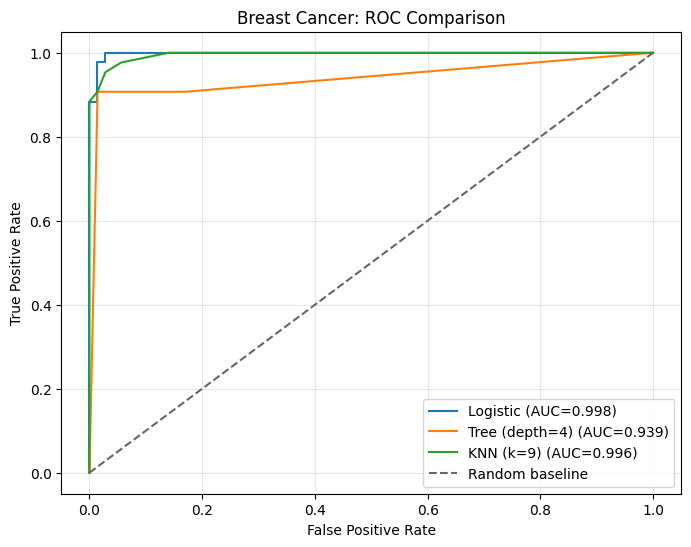

{'ax': <Axes: title={'center': 'Breast Cancer: ROC Comparison'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
 'data': {'Logistic': {'data':    threshold       fpr       tpr
   0        inf  0.000000  0.000000
   1   1.000000  0.000000  0.023256
   2   0.916221  0.000000  0.883721
   3   0.878629  0.014085  0.883721
   4   0.291206  0.014085  0.976744
   5   0.264375  0.028169  0.976744
   6   0.161035  0.028169  1.000000
   7   0.000010  1.000000  1.000000,
   'auc': 0.9980347199475925,
   'best_cutoff': 0.2912056813253728,
   'best_fpr': 0.014084507042253521,
   'best_tpr': 0.9767441860465116,
   'best_distance': 0.027188347159446},
  'Tree (depth=4)': {'data':    threshold       fpr       tpr
   0        inf  0.000000  0.000000
   1   1.000000  0.014085  0.883721
   2   0.500000  0.014085  0.906977
   3   0.085714  0.169014  0.906977
   4   0.000000  1.000000  1.000000,
   'auc': 0.9390763183753684,
   'best_cutoff': 0.5,
   'best_fpr': 0.014084507042253521,
   'best_

In [4]:
roc_out = ca.plot_roc(
    models=models,
    test_df=test_df,
    positive_class='M',
    model_names=model_names,
    title='Breast Cancer: ROC Comparison'
)


# Returned data is available in roc_out['data']
roc_out

## 4) Lift Curve

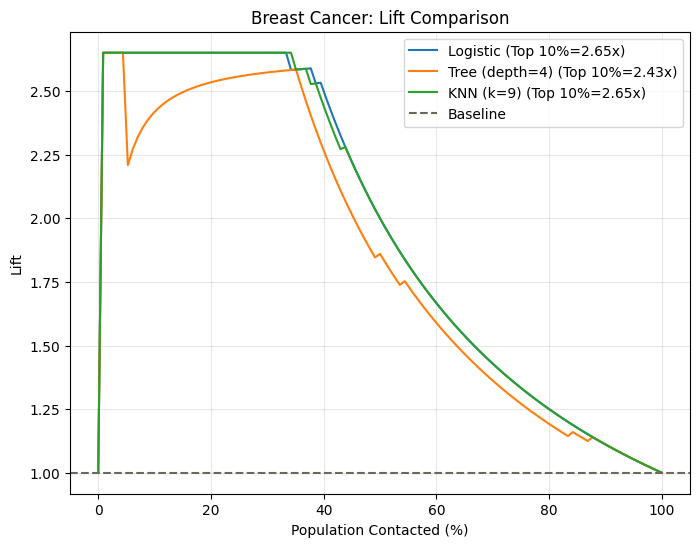

{'Logistic': 2.651, 'Tree (depth=4)': 2.43, 'KNN (k=9)': 2.651}

In [5]:
lift_out = ca.plot_lift(
    models=models,
    test_df=test_df,
    positive_class='M',
    model_names=model_names,
    title='Breast Cancer: Lift Comparison'
)


# Example: top-decile lift summary
{name: round(info['top_decile_lift'], 3) for name, info in lift_out['data'].items()}


## 5) Profit Curve

`*_value` convention: use positive values for gains and negative values for losses/costs.

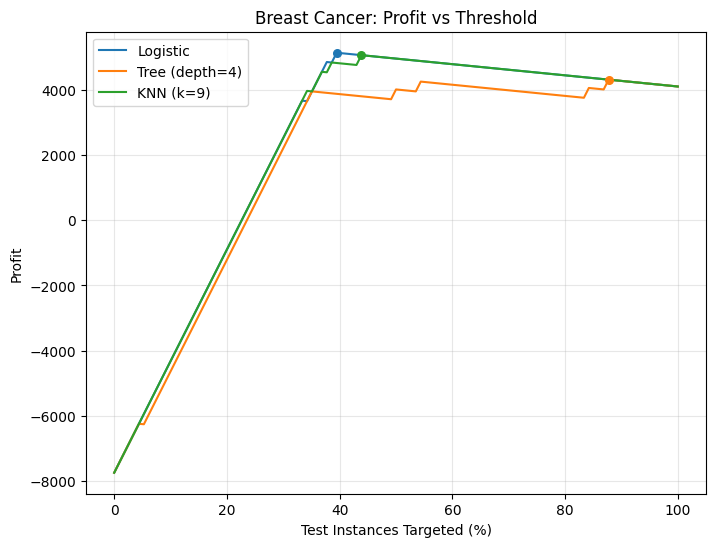

,max_profit,best_threshold
Logistic,5130.0,0.161035
Tree (depth=4),4305.0,0.000000
KNN (k=9),5055.0,0.222222


In [6]:
profit_config = {
    'tp_value': 120.0,
    'fp_value': -15.0,
    'tn_value': 0.0,
    'fn_value': -180.0,
    'fixed_value': 0.0,
}

profit_out = ca.plot_profit(
    models=models,
    test_df=test_df,
    positive_class='M',
    model_names=model_names,
    profit_config=profit_config,
    title='Breast Cancer: Profit vs Threshold'
)


pd.DataFrame({
    name: {
        'max_profit': info['max_profit'],
        'best_threshold': info['max_profit_threshold']
    }
    for name, info in profit_out['data'].items()
}).T


## 6) Cumulative Response Curve

Shows cumulative capture of positives as you contact more of the population ranked by model score.

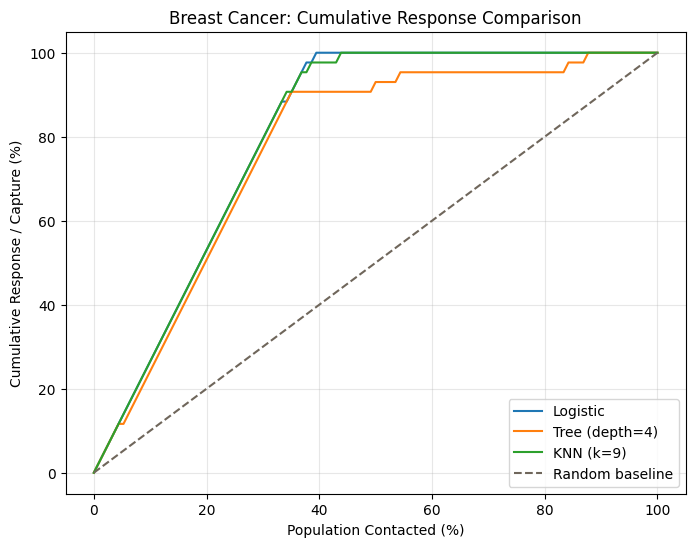

,threshold,population_frac,capture_rate,lift
0,1.0,0.000000,0.000000,1.000000
1,1.0,0.008772,0.023256,2.651163
2,1.0,0.017544,0.046512,2.651163
3,1.0,0.026316,0.069767,2.651163
4,1.0,0.035088,0.093023,2.651163


In [7]:
cum_out = ca.plot_cumulative_response(
    models=models,
    test_df=test_df,
    positive_class='M',
    model_names=model_names,
    title='Breast Cancer: Cumulative Response Comparison'
)

# Example: show the first few rows for one model
first_name = model_names[0]
cum_out['data'][first_name]['data'].head()


## 7) Optional: single-model usage\n
\n
Each helper also accepts a single model object directly.

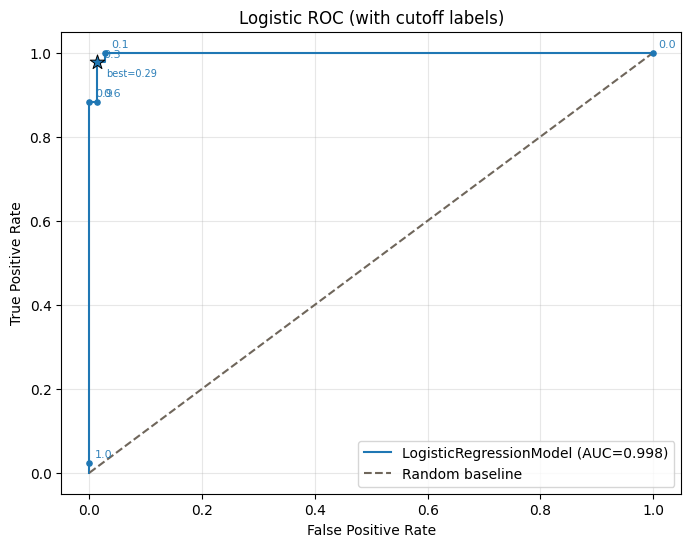

{'ax': <Axes: title={'center': 'Logistic ROC (with cutoff labels)'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
 'data': {'LogisticRegressionModel': {'data':    threshold       fpr       tpr
   0        inf  0.000000  0.000000
   1   1.000000  0.000000  0.023256
   2   0.916221  0.000000  0.883721
   3   0.878629  0.014085  0.883721
   4   0.291206  0.014085  0.976744
   5   0.264375  0.028169  0.976744
   6   0.161035  0.028169  1.000000
   7   0.000010  1.000000  1.000000,
   'auc': 0.9980347199475925,
   'best_cutoff': 0.2912056813253728,
   'best_fpr': 0.014084507042253521,
   'best_tpr': 0.9767441860465116,
   'best_distance': 0.027188347159446}}}

In [8]:
# Optional: single-model usage with cutoff labels on the ROC curve
_single = ca.plot_roc(
    logit,
    test_df=test_df,
    positive_class='M',
    title='Logistic ROC (with cutoff labels)',
    show_cutoffs=True,
    cutoff_step=0.1,
    cutoff_fontsize=8,
)
_single

In [9]:
logit.score(test_df, threshold=0.29, positive_class='M')
logit.score(test_df, threshold=0.5, positive_class='M')


SCORE REPORT
Accuracy: 98.25%
Kappa: 0.9627

Confusion Matrix:
        Actual M  Actual B
Pred M        42         1
Pred B         1        70

Per-Class Metrics:
   precision  recall  sensitivity  specificity     f1
B     0.9859  0.9859       0.9859       0.9767 0.9859
M     0.9767  0.9767       0.9767       0.9859 0.9767

SCORE REPORT
Accuracy: 95.61%
Kappa: 0.9053

Confusion Matrix:
        Actual M  Actual B
Pred M        39         1
Pred B         4        70

Per-Class Metrics:
   precision  recall  sensitivity  specificity     f1
B     0.9459  0.9859       0.9859       0.9070 0.9655
M     0.9750  0.9070       0.9070       0.9859 0.9398


{'accuracy': np.float64(0.956140350877193),
 'kappa': np.float64(0.9053470607771504),
 'confusion_matrix': array([[70,  1],
        [ 4, 39]]),
 'classes': ['B', 'M'],
 'per_class': {'B': {'precision': np.float64(0.9459459459459459),
   'recall': np.float64(0.9859154929577465),
   'sensitivity': np.float64(0.9859154929577465),
   'specificity': np.float64(0.9069767441860465),
   'f1': np.float64(0.9655172413793103)},
  'M': {'precision': np.float64(0.975),
   'recall': np.float64(0.9069767441860465),
   'sensitivity': np.float64(0.9069767441860465),
   'specificity': np.float64(0.9859154929577465),
   'f1': np.float64(0.9397590361445783)}},
 'macro_precision': 0.960472972972973,
 'macro_recall': 0.9464461185718964,
 'macro_specificity': 0.9464461185718964,
 'macro_f1': 0.9526381387619443,
 'positive_label': 'M',
 'binary_counts': {'tp': np.int64(39),
  'fp': np.int64(1),
  'fn': np.int64(4),
  'tn': np.int64(70)},
 'sensitivity': np.float64(0.9069767441860465),
 'specificity': np.float